In [94]:
from bird import Bird, Species
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from glob import glob
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import random 
import librosa
from tqdm import tqdm

SR=12000
NMELS=100
 
BATCHSIZE=10000
NCLUSTERS=500
R = 10 # reshape parameter, unwrap this many rows of mels

In [95]:
def reshape_by_rows(x, r):
    n, m = x.shape
    # Calculate how many complete sets of r rows we can use
    complete_sets = n // r
    # Truncate x to use only the complete sets of rows
    x_truncated = x[:complete_sets * r]
    
    return x_truncated.reshape(complete_sets, r, m).reshape(complete_sets, m*r)
    

# train k-means

In [96]:
fnames = glob("/Users/gary/Downloads/birdsong-recognition/train_audio/**/*mp3")
kmeans = MiniBatchKMeans(n_clusters=NCLUSTERS) 

batch = np.zeros((1,NMELS*R))
for f in tqdm(fnames[:10000]):
    x, sr = librosa.load(f , sr= SR)
    mels = librosa.feature.melspectrogram(y=x, n_mels=NMELS)
    mels = np.log(np.abs(mels+1e-7)).T
    #print(mels.shape)
    mels = reshape_by_rows(mels,R)
    batch = np.vstack([batch, mels])
    if(batch.shape[0]>BATCHSIZE):    
        kmeans.partial_fit(batch)
        batch = np.zeros((1,NMELS*R))


  0%|▏                                                                       | 30/10000 [00:02<09:22, 17.72it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 752243.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  1%|▍                                                                       | 69/10000 [00:07<19:02,  8.69it/s]/Users/gary/miniconda3/envs/tf_gpu/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
  1%|▊                                                                      | 121/10000 [00:13<15:23, 10.70it/s]Note: Illegal Audio-MPEG-Header 0x2c202d34 at offset 668652.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  1%|▉                                                                      | 136/10000 [00:15<16:3

 20%|██████████████                                                        | 2002/10000 [03:21<06:21, 20.98it/s]Note: Illegal Audio-MPEG-Header 0x616e6420 at offset 980992.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 21%|███████████████                                                       | 2147/10000 [03:30<09:55, 13.19it/s]Note: Illegal Audio-MPEG-Header 0x65727065 at offset 256962.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 22%|███████████████                                                       | 2157/10000 [03:31<09:51, 13.25it/s]Note: Illegal Audio-MPEG-Header 0x75732907 at offset 591329.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 24%|████████████████▋                                                     | 2382/10000 [03:49<09:24, 13.49it/s]Note: Illegal Audio-MPEG-Header 0x682c2032 at offset 444625.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 25%|███

 37%|█████████████████████████▌                                            | 3658/10000 [05:55<11:43,  9.01it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 400321.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 38%|██████████████████████████▍                                           | 3771/10000 [06:09<13:45,  7.54it/s]Warning: Xing stream size off by more than 1%, fuzzy seeking may be even more fuzzy than by design!
Note: Illegal Audio-MPEG-Header 0x61727420 at offset 842523.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 40%|███████████████████████████▋                                          | 3953/10000 [06:27<05:48, 17.33it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 306907.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 40%|████████████████████████████▎                                         | 4039/10000 [06:39<13:14,  7.50it/s]Note: Illegal Audio-MPEG-Header 0x65642053 a

 50%|███████████████████████████████████▎                                  | 5048/10000 [08:06<11:44,  7.03it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 4171985.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 51%|███████████████████████████████████▍                                  | 5054/10000 [08:07<10:41,  7.71it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 750153.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 51%|███████████████████████████████████▊                                  | 5113/10000 [08:13<08:15,  9.86it/s]Note: Illegal Audio-MPEG-Header 0x4e524500 at offset 2067977.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 56%|███████████████████████████████████████▏                              | 5596/10000 [09:03<03:02, 24.08it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 394679.
Note: Trying to resync...
/var/folders/_q/tcgs8dld2dx2rf07xv0wgmk00000gp/T/ipyker

 64%|████████████████████████████████████████████▍                         | 6350/10000 [10:18<02:23, 25.44it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 186535.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 64%|████████████████████████████████████████████▌                         | 6368/10000 [10:19<02:20, 25.94it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 356227.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 64%|████████████████████████████████████████████▊                         | 6401/10000 [10:22<09:08,  6.56it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 1197369.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 64%|████████████████████████████████████████████▉                         | 6413/10000 [10:24<08:33,  6.99it/s]Note: Illegal Audio-MPEG-Header 0x50455441 at offset 1085565.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 66%|█

 79%|███████████████████████████████████████████████████████               | 7866/10000 [13:08<01:35, 22.26it/s]Note: Illegal Audio-MPEG-Header 0xa26e6961 at offset 415995.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 79%|███████████████████████████████████████████████████████▏              | 7884/10000 [13:09<01:24, 24.90it/s]Note: Illegal Audio-MPEG-Header 0x00415045 at offset 59893.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 79%|███████████████████████████████████████████████████████▌              | 7934/10000 [13:11<01:17, 26.49it/s]Note: Illegal Audio-MPEG-Header 0xa1732028 at offset 743257.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 80%|███████████████████████████████████████████████████████▋              | 7961/10000 [13:13<02:34, 13.21it/s]Note: Illegal Audio-MPEG-Header 0x650f0000 at offset 801563.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 80%|████

 97%|████████████████████████████████████████████████████████████████████  | 9723/10000 [16:37<00:47,  5.84it/s]Note: Illegal Audio-MPEG-Header 0x41525449 at offset 311714.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 98%|████████████████████████████████████████████████████████████████████▍ | 9785/10000 [16:42<00:21,  9.86it/s]Note: Illegal Audio-MPEG-Header 0x313a3330 at offset 225615.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 99%|█████████████████████████████████████████████████████████████████████▎| 9909/10000 [16:53<00:08, 11.32it/s]Note: Illegal Audio-MPEG-Header 0x0a000000 at offset 447551.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
100%|█████████████████████████████████████████████████████████████████████| 10000/10000 [17:01<00:00,  9.79it/s]


# Test 

In [97]:
def buildBatchFromFiles(fnames):
    batch = np.zeros((1, NMELS*R))
    for f in tqdm(fnames):
        x, sr = librosa.load(f , sr= SR)
        mels = librosa.feature.melspectrogram(y=x, n_mels=NMELS)
        mels = np.log(np.abs(mels+1e-7)).T
        mels = reshape_by_rows(mels,R)
        batch = np.vstack([batch, mels])
    return batch

test_batch = buildBatchFromFiles(fnames[16000:16500])

 13%|█████████▌                                                                | 65/500 [00:06<00:29, 14.78it/s]Note: Illegal Audio-MPEG-Header 0x2e363132 at offset 230421.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 25%|██████████████████▌                                                      | 127/500 [00:11<00:42,  8.71it/s]Note: Illegal Audio-MPEG-Header 0x65643a6e at offset 658620.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
 51%|████████████████████████████████████▉                                    | 253/500 [00:30<01:05,  3.77it/s]Note: Illegal Audio-MPEG-Header 0x70686167 at offset 147456.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
100%|█████████████████████████████████████████████████████████████████████████| 500/500 [01:19<00:00,  6.30it/s]


In [119]:
from bird import Species
blujay = Species("blujay")
cardinal = Species("norcar")
robin = Species("amerob")
loon = Species("comloo")


#batch_cardinal = buildBatchFromFiles(cardinal.fnames[:5])
#batch_robin = buildBatchFromFiles(robin.fnames[:5])
#colors = [batch_robin.shape[0], batch_cardinal.shape

x = buildBatchFromFiles([cardinal.fnames[0]])
 

100%|█████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.79it/s]


Text(0.5, 1.0, 'Embedding With 500 Clusters')

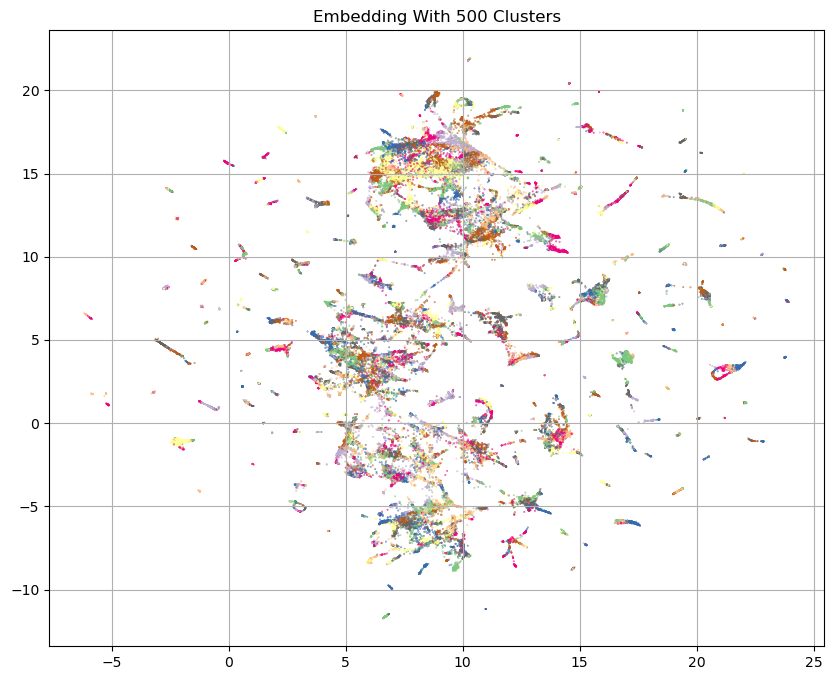

In [98]:
mapper = UMAP().fit_transform(test_batch)
plt.figure(figsize=(10,8))
plt.scatter(mapper[:,0], mapper[:,1], s=.1,c = kmeans.predict(test_batch), cmap='Accent')
plt.grid()
plt.title(f"Embedding With {NCLUSTERS} Clusters")

In [167]:
r = buildBatchFromFiles([random.choice(robin.fnames)])
l = buildBatchFromFiles([random.choice(loon.fnames)])
r = set(kmeans.predict(r))
l = set(kmeans.predict(l))
r & l 

100%|█████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.68it/s]


{4}